# Projeção Preditiva de Indicadores

### Metodo usando o algoritmo "Prophet"

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
import warnings

warnings.filterwarnings('ignore')

try:
    df = pd.read_excel('Embrapii_seleção_analista_2026_questao03_Estimativa.xlsx', sheet_name='dados')
except Exception as e:
    try:
        df = pd.read_csv('Embrapii_seleção_analista_2026_questao03_Estimativa.xlsx - dados.csv')
    except Exception as ex:
        print(f"Erro fatal ao carregar dados: {ex}")

c:\Users\guilh\Documents\embrapii\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [2]:
try:
    df['ds'] = pd.to_datetime(df['ano'].astype(str) + '-' + df['mes'].astype(str) + '-01')
    metricas = ['novos_projetos_contratados', 'valor_projetos_contratados', 'projetos_concluidos']
except Exception as e:
    print(f"Erro ao preparar os tensores de data: {e}")

In [3]:
try:
    resultados_finais = pd.DataFrame({'ano': [2024, 2025, 2026, 2027]})
    dados_plotagem = {}

    for col in metricas:
        df_prophet = df[['ds', col]].rename(columns={col: 'y'})
        
        modelo = Prophet(yearly_seasonality=True, interval_width=0.90)
        modelo.fit(df_prophet)
        
        futuro = modelo.make_future_dataframe(periods=48, freq='MS')
        previsao = modelo.predict(futuro)
        
        dados_plotagem[col] = previsao
        
        previsao['ano'] = previsao['ds'].dt.year
        prev_anual = previsao[previsao['ano'].isin([2024, 2025, 2026, 2027])].groupby('ano')[['yhat', 'yhat_lower', 'yhat_upper']].sum().reset_index()
        
        resultados_finais[col] = prev_anual['yhat'].round(2)
        resultados_finais[f'{col}_lim_inf'] = prev_anual['yhat_lower'].clip(lower=0).round(2)
        resultados_finais[f'{col}_lim_sup'] = prev_anual['yhat_upper'].round(2)
        
except Exception as e:
    print(f"Erro na modelagem preditiva com Prophet: {e}")

23:35:17 - cmdstanpy - INFO - Chain [1] start processing
23:35:21 - cmdstanpy - INFO - Chain [1] done processing
23:35:21 - cmdstanpy - INFO - Chain [1] start processing
23:35:21 - cmdstanpy - INFO - Chain [1] done processing
23:35:22 - cmdstanpy - INFO - Chain [1] start processing
23:35:22 - cmdstanpy - INFO - Chain [1] done processing


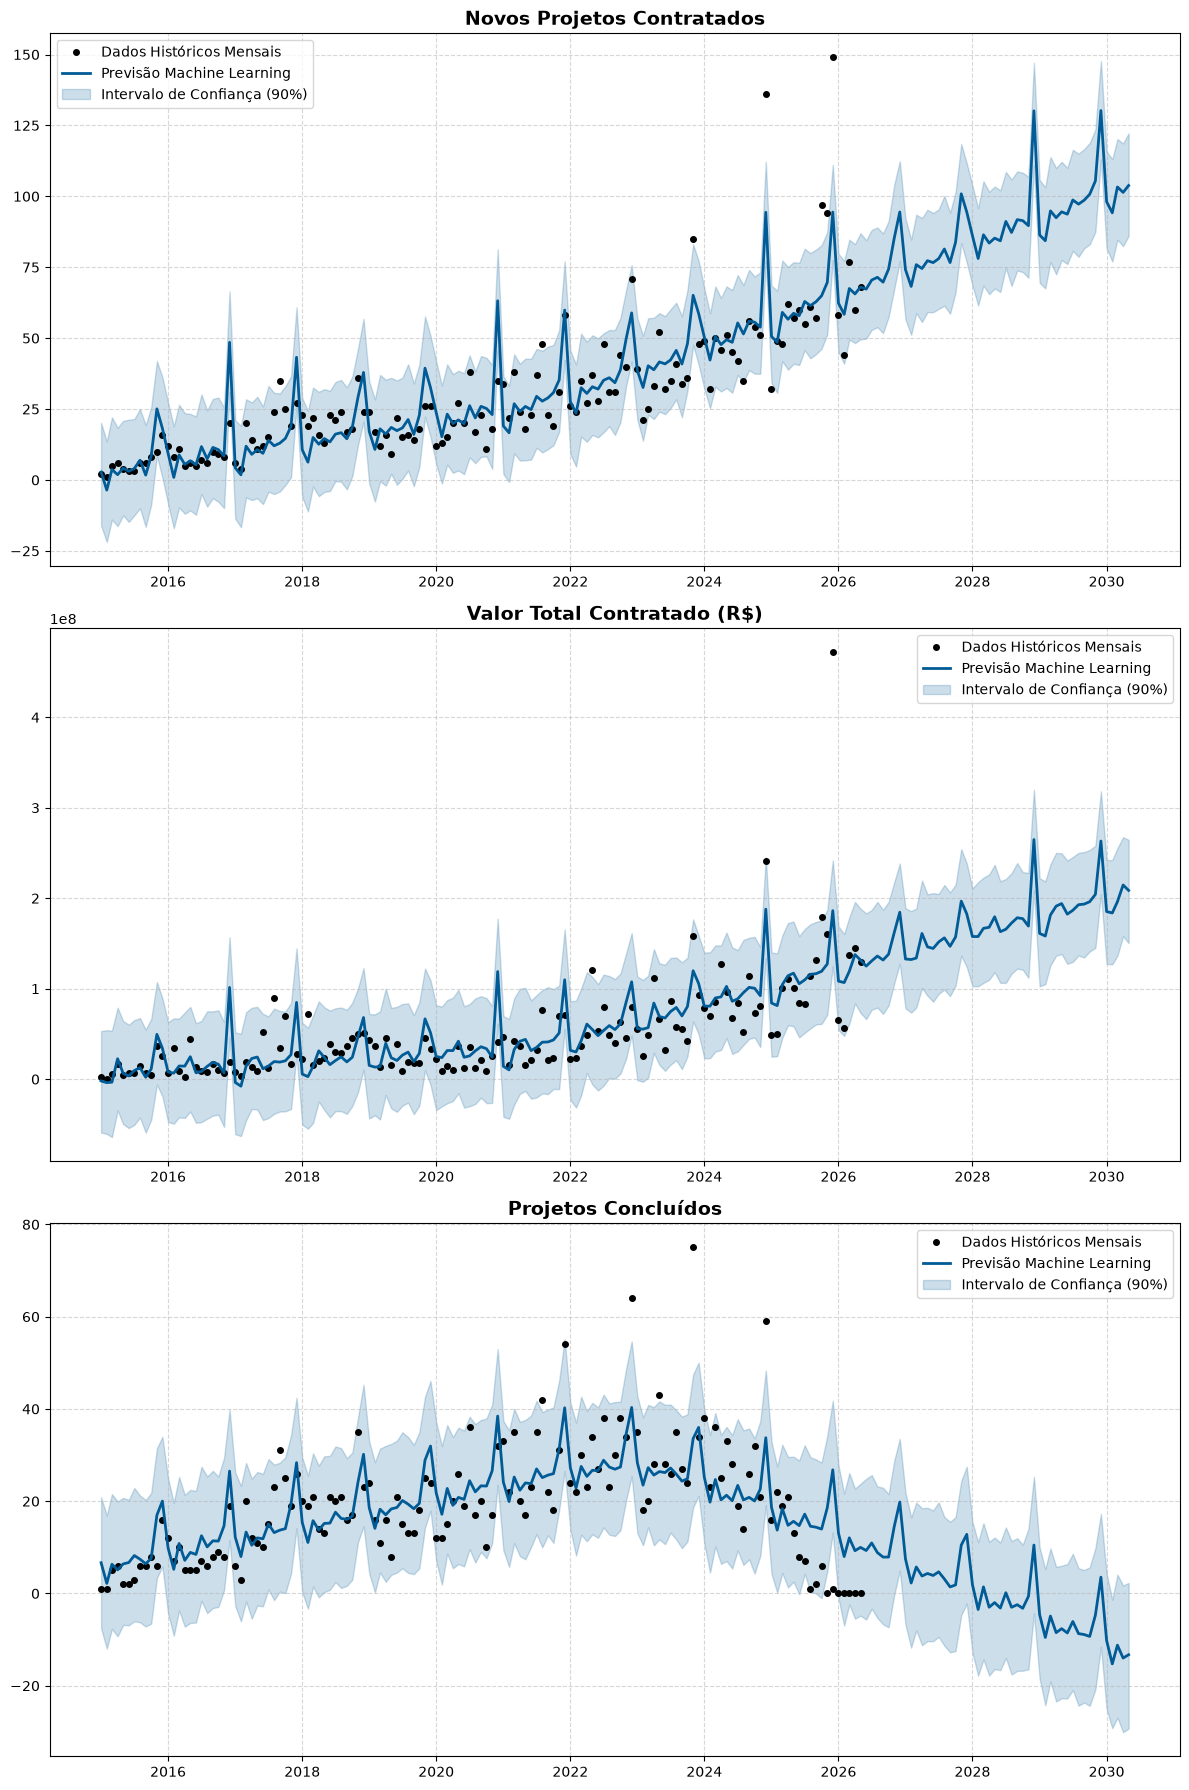

In [4]:
try:
    fig, axes = plt.subplots(3, 1, figsize=(12, 18))
    titulos = ['Novos Projetos Contratados', 'Valor Total Contratado (R$)', 'Projetos Concluídos']

    for i, col in enumerate(metricas):
        ax = axes[i]
        prev = dados_plotagem[col]
        historico = df[['ds', col]]
        
        ax.plot(historico['ds'], historico[col], 'ko', markersize=4, label='Dados Históricos Mensais')
        ax.plot(prev['ds'], prev['yhat'], color='#005b96', linewidth=2, label='Previsão Machine Learning')
        ax.fill_between(prev['ds'], prev['yhat_lower'], prev['yhat_upper'], color='#005b96', alpha=0.2, label='Intervalo de Confiança (90%)')
        
        ax.set_title(titulos[i], fontsize=14, fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend()
        
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Erro ao gerar gráficos preditivos: {e}")

In [5]:
try:
    resultado_2027 = resultados_finais[resultados_finais['ano'] == 2027]
    display(resultado_2027)
except Exception as e:
    print(f"Erro ao extrair resultados projetados: {e}")

,ano,novos_projetos_contratados,novos_projetos_contratados_lim_inf,novos_projetos_contratados_lim_sup,valor_projetos_contratados,valor_projetos_contratados_lim_inf,valor_projetos_contratados_lim_sup,projetos_concluidos,projetos_concluidos_lim_inf,projetos_concluidos_lim_sup
3,2027,962.12,747.32,1173.56,1.842429e+09,1.158857e+09,2.526622e+09,61.92,0.0,233.4


### Metodo usando regressão linear

In [12]:
import statsmodels.api as sm
import numpy as np

In [6]:
try:
    df = pd.read_excel('Embrapii_seleção_analista_2026_questao03_Estimativa.xlsx', sheet_name='dados')
except Exception as e:
    try:
        df = pd.read_csv('Embrapii_seleção_analista_2026_questao03_Estimativa.xlsx - dados.csv')
    except Exception as ex:
        print(f"Erro fatal ao carregar dados: {ex}")

In [7]:
try:
    df_anual = df.groupby('ano')[['novos_projetos_contratados', 'valor_projetos_contratados', 'projetos_concluidos']].sum().reset_index()
except Exception as e:
    print(f"Erro ao agrupar dados anuais: {e}")

In [13]:
try:
    anos_futuros = pd.DataFrame({'ano': [2024, 2025, 2026, 2027]})
    resultados_projecao = anos_futuros.copy()
    
    for col in ['novos_projetos_contratados', 'valor_projetos_contratados', 'projetos_concluidos']:
        X = df_anual['ano']
        y = df_anual[col]
        X_sm = sm.add_constant(X)
        modelo = sm.OLS(y, X_sm).fit()
        
        X_fut_sm = sm.add_constant(anos_futuros['ano'])
        previsoes = modelo.get_prediction(X_fut_sm)
        resumo_prev = previsoes.summary_frame(alpha=0.10)
        
        resultados_projecao[col] = resumo_prev['mean'].round(2)
        resultados_projecao[f'{col}_lim_inf'] = np.maximum(0, resumo_prev['obs_ci_lower']).round(2)
        resultados_projecao[f'{col}_lim_sup'] = resumo_prev['obs_ci_upper'].round(2)
        
except Exception as e:
    print(f"Erro ao processar as projeções estatísticas: {e}")

In [14]:
try:
    df_anual = df.groupby('ano')[['novos_projetos_contratados', 'valor_projetos_contratados', 'projetos_concluidos']].sum().reset_index()
except Exception as e:
    print(f"Erro ao agrupar dados anuais: {e}")

In [15]:
try:
    anos_futuros = pd.DataFrame({'ano': [2024, 2025, 2026, 2027]})
    resultados_projecao = anos_futuros.copy()
    
    for col in ['novos_projetos_contratados', 'valor_projetos_contratados', 'projetos_concluidos']:
        X = df_anual['ano']
        y = df_anual[col]
        X_sm = sm.add_constant(X)
        modelo = sm.OLS(y, X_sm).fit()
        
        X_fut_sm = sm.add_constant(anos_futuros['ano'])
        previsoes = modelo.get_prediction(X_fut_sm)
        resumo_prev = previsoes.summary_frame(alpha=0.10)
        
        resultados_projecao[col] = resumo_prev['mean'].round(2)
        resultados_projecao[f'{col}_lim_inf'] = np.maximum(0, resumo_prev['obs_ci_lower']).round(2)
        resultados_projecao[f'{col}_lim_sup'] = resumo_prev['obs_ci_upper'].round(2)
        
except Exception as e:
    print(f"Erro ao processar as projeções estatísticas: {e}")

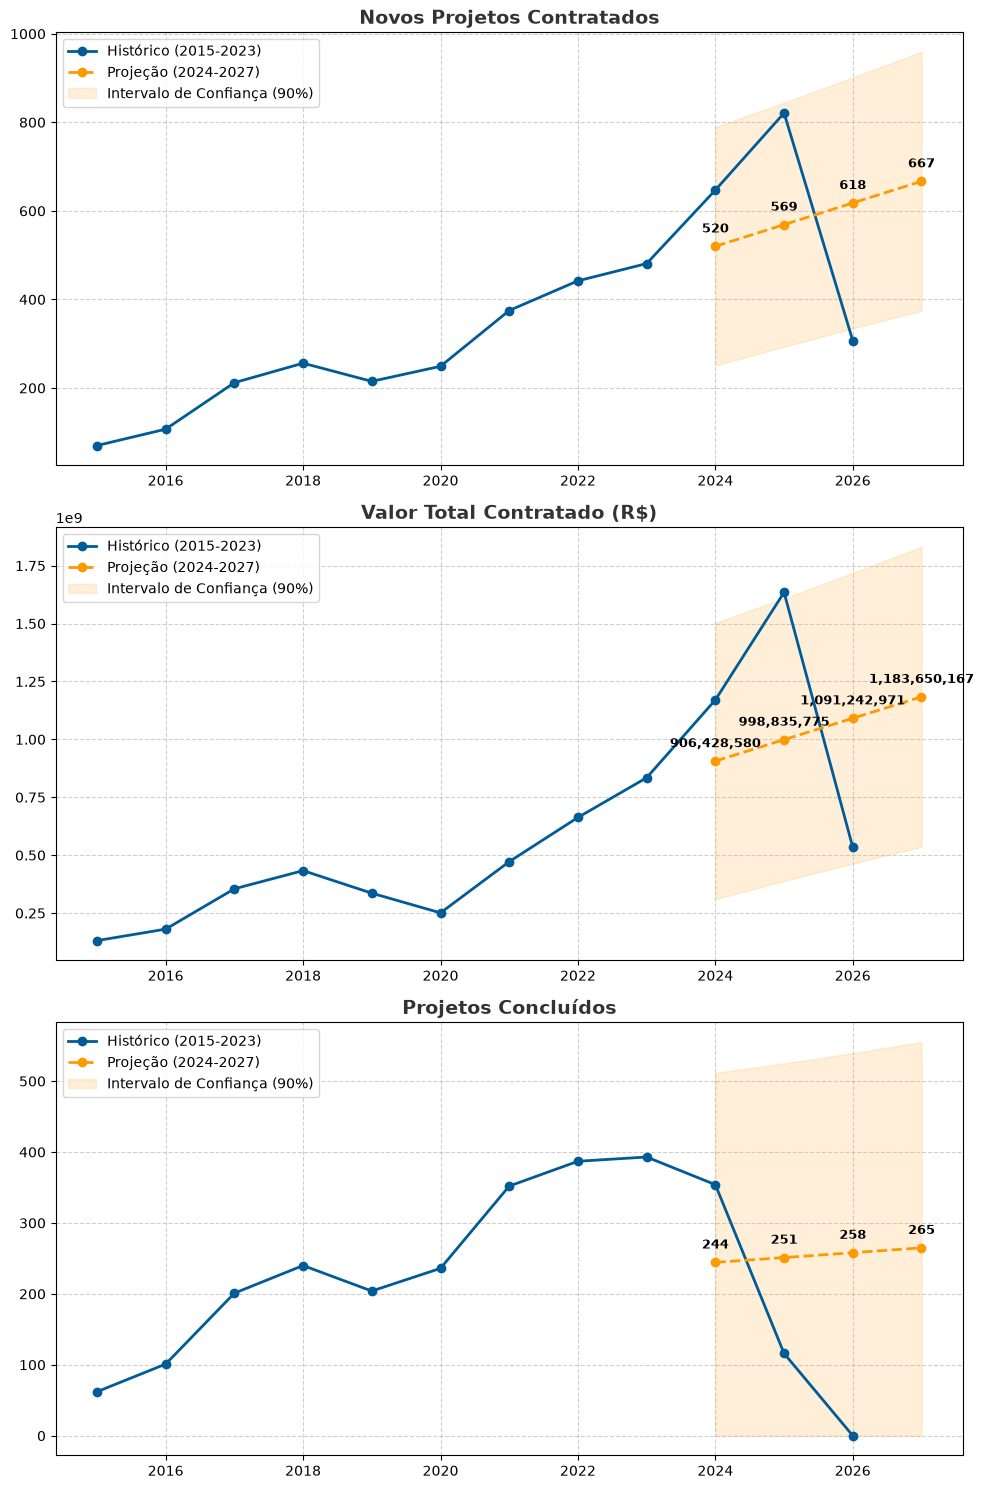

In [16]:
try:
    fig, axes = plt.subplots(3, 1, figsize=(10, 15))
    metricas = ['novos_projetos_contratados', 'valor_projetos_contratados', 'projetos_concluidos']
    titulos = ['Novos Projetos Contratados', 'Valor Total Contratado (R$)', 'Projetos Concluídos']
    
    for i, col in enumerate(metricas):
        ax = axes[i]
        ax.plot(df_anual['ano'], df_anual[col], marker='o', label='Histórico (2015-2023)', color='#005b96', linewidth=2)
        ax.plot(resultados_projecao['ano'], resultados_projecao[col], marker='o', linestyle='--', label='Projeção (2024-2027)', color='#ff9900', linewidth=2)
        ax.fill_between(resultados_projecao['ano'], resultados_projecao[f'{col}_lim_inf'], resultados_projecao[f'{col}_lim_sup'], color='#ff9900', alpha=0.15, label='Intervalo de Confiança (90%)')
        
        ax.set_title(titulos[i], fontsize=14, fontweight='bold', color='#333333')
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.6)
        
        for index, row in resultados_projecao.iterrows():
            ax.annotate(f"{row[col]:,.0f}", (row['ano'], row[col]), textcoords="offset points", xytext=(0,10), ha='center', fontsize=9, fontweight='bold')
            
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Erro ao gerar visualizações: {e}")

In [17]:
try:
    resultado_2027 = resultados_projecao[resultados_projecao['ano'] == 2027]
    display(resultado_2027)
except Exception as e:
    print(f"Erro ao extrair resultados finais: {e}")

,ano,novos_projetos_contratados,novos_projetos_contratados_lim_inf,novos_projetos_contratados_lim_sup,valor_projetos_contratados,valor_projetos_contratados_lim_inf,valor_projetos_contratados_lim_sup,projetos_concluidos,projetos_concluidos_lim_inf,projetos_concluidos_lim_sup
3,2027,666.91,374.54,959.28,1.183650e+09,5.362204e+08,1.831080e+09,264.91,0.0,555.26
